In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

news = pd.read_csv('../data/raw/raw_analyst_ratings.csv', index_col=0, parse_dates=['date'])
print("News shape:", news.shape)
print("Columns:", news.columns.tolist())
news.head(2)

News shape: (1407328, 5)
Columns: ['headline', 'url', 'publisher', 'date', 'stock']


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A


In [3]:
news['headline_len'] = news['headline'].str.len()
news['headline_len'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

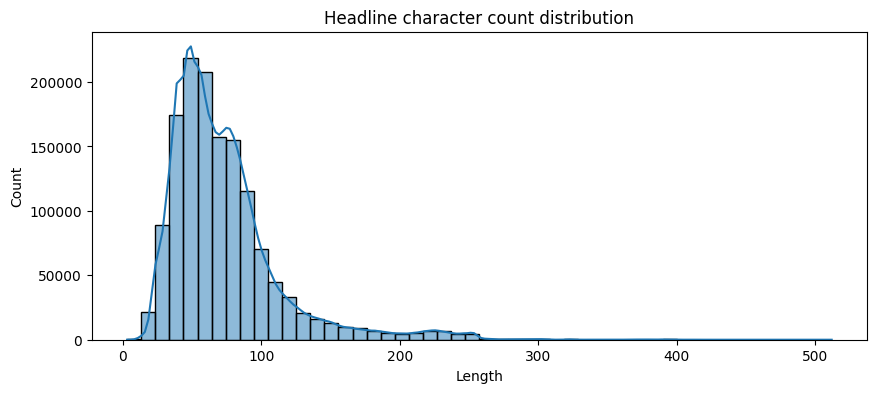

In [5]:
plt.figure(figsize=(10,4))
sns.histplot(news['headline_len'], bins=50, kde=True)
plt.title('Headline character count distribution')
plt.xlabel('Length')
plt.show()

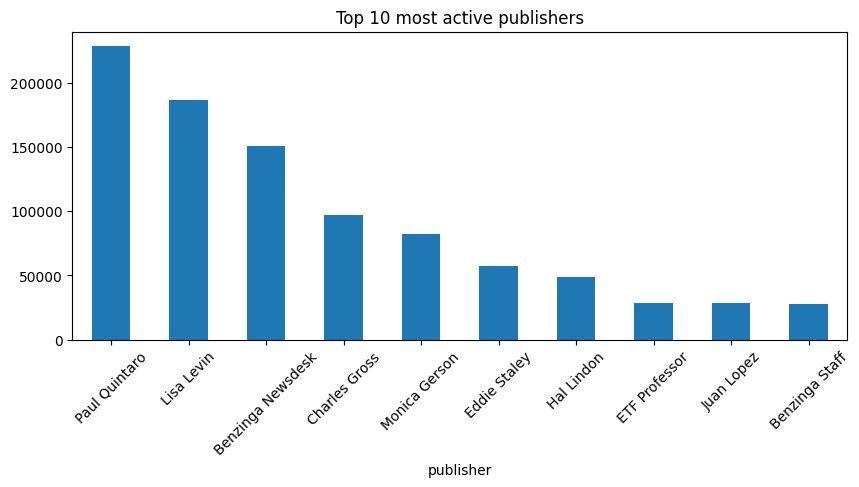

In [6]:
top_pubs = news['publisher'].value_counts().head(10)
top_pubs.plot(kind='bar', figsize=(10,4))
plt.title('Top 10 most active publishers')
plt.xticks(rotation=45)
plt.show()

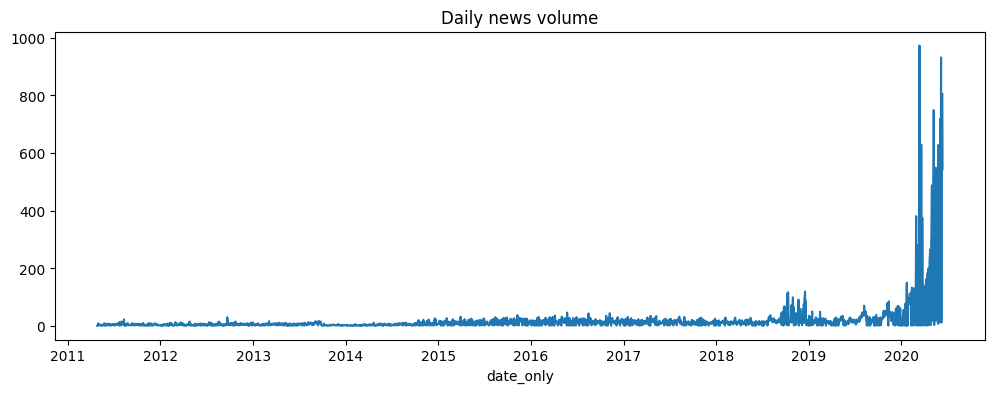

In [7]:
import pandas as pd

# Convert to datetime, coerce errors to NaT
news['date'] = pd.to_datetime(news['date'], errors='coerce')

# Drop rows with NaT (if any)
news = news.dropna(subset=['date'])

# Extract date only (without time)
news['date_only'] = news['date'].dt.date

# Count per day
daily_counts = news.groupby('date_only').size()

# Plot
daily_counts.plot(figsize=(12,4), title='Daily news volume')
plt.show()

In [14]:
sample = news['headline'].dropna().sample(10000, random_state=42)
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english', max_features=1000)
dtm = vectorizer.fit_transform(sample)
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

def show_topics(model, feature_names, n_words=8):
    for idx, topic in enumerate(model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_words-1:-1]]
        print(f"Topic {idx}: {', '.join(words)}")

show_topics(lda, vectorizer.get_feature_names_out())

Topic 0: shares, trading, companies, higher, amid, lower, following, coronavirus
Topic 1: stocks, session, market, moving, etfs, mid, day, etf
Topic 2: eps, sales, estimate, q1, yoy, vs, reports, est
Topic 3: stocks, week, 52, hit, lows, yesterday, new, highs
Topic 4: price, target, maintains, shares, raises, announces, buy, lowers
